# URL-Based Phishing Website Detection Using Machine Learning and Artificial Neural Networks
**Formative Assessment 1 (FA1) / Machine Learning Project**  
*Authors: Christy Francis (124B1B005), Saksham Joshi (124B1B021), Aadesh Patil (124B1B023)*  
*Department of Computer Engineering, Pimpri Chinchwad College of Engineering, Pune*

---

### Pipeline Structure:
1. **Import Libraries**
2. **Load Dataset**
3. **Explore Dataset (EDA)**
4. **Data Preprocessing & Visualizations**
   - Missing Values & Duplicate Records
   - Target Class Distribution & Visualization (Fig. 1)
   - HTTPS Usage Analysis & Visualization (Fig. 2)
   - Dropping Non-Predictive Text Columns
   - Target Leakage Screening & Removal (URLSimilarityIndex, TLDLegitimateProb)
   - Feature Correlation Heatmap (Fig. 3)
   - Splitting Features & Target
5. **Feature Selection (SelectKBest with Mutual Information)**
   - Computing MI Scores
   - Top 20 Feature Importance Bar Plot (Fig. 4)
   - Top 30 Selected Features
6. **Train-Test Split (Stratified 80/20)**
7. **Feature Scaling (StandardScaler fitted strictly on training data)**
8. **Build Proposed Artificial Neural Network (ANN)**
9. **Train Proposed ANN Model (with Dropout & Early Stopping)**
   - Training vs Validation Curves (Fig. 5)
10. **Evaluate Model on Held-Out Test Set**
    - Confusion Matrix (TP, TN, FP, FN with False Negative highlighted) & Heatmap (Fig. 6)
    - Performance Metrics: Accuracy, Precision, Recall, F1-Score, ROC-AUC (Table 4)
11. **Feature Selection Ablation Study (Section 13, Table 7)**
12. **Comparison with Traditional Machine Learning Models (Section 12, Table 6)**
    - Logistic Regression, Decision Tree, Random Forest, LinearSVC, XGBoost
    - Performance Comparison Bar Chart (Fig. 7)


## 1. Import Libraries


In [1]:
import os
import sys
import time
import pickle
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress non-critical warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# Scikit-Learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# XGBoost
from xgboost import XGBClassifier

# TensorFlow & Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
print("Libraries imported successfully!")


Libraries imported successfully!


## 2. Load Dataset


In [2]:
# Load PhiUSIIL Phishing URL Dataset
csv_filename = "PhiUSIIL_Phishing_URL_Dataset.csv"
df = pd.read_csv(csv_filename)

print("Dataset Loaded Successfully!")
print(f"Total Rows: {df.shape[0]:,} | Total Columns: {df.shape[1]}")
df.head()


Dataset Loaded Successfully!
Total Rows: 235,795 | Total Columns: 56


,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,521848.txt,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,...,0,0,1,34,20,28,119,0,124,1
1,31372.txt,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,...,0,0,1,50,9,8,39,0,217,1
2,597387.txt,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,...,0,0,1,10,2,7,42,2,5,1
3,554095.txt,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,...,1,1,1,3,27,15,22,1,31,1
4,151578.txt,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,...,1,0,1,244,15,34,72,1,85,1


## 3. Explore Dataset (EDA)


In [3]:
# Check column types, memory usage, and non-null counts
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235795 entries, 0 to 235794
Data columns (total 56 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   FILENAME                    235795 non-null  object 
 1   URL                         235795 non-null  object 
 2   URLLength                   235795 non-null  int64  
 3   Domain                      235795 non-null  object 
 4   DomainLength                235795 non-null  int64  
 5   IsDomainIP                  235795 non-null  int64  
 6   TLD                         235795 non-null  object 
 7   URLSimilarityIndex          235795 non-null  float64
 8   CharContinuationRate        235795 non-null  float64
 9   TLDLegitimateProb           235795 non-null  float64
 10  URLCharProb                 235795 non-null  float64
 11  TLDLength                   235795 non-null  int64  
 12  NoOfSubDomain               235795 non-null  int64  
 13  HasObfuscation

In [4]:
# Dataset dimensions
print("Shape of dataset:", df.shape)


Shape of dataset: (235795, 56)


In [5]:
# Statistical summary of numerical features
df.describe().T.head(15)


,count,mean,std,min,25%,50%,75%,max
URLLength,235795.0,34.573095,41.314153,13.000000,23.000000,27.000000,34.000000,6097.000000
DomainLength,235795.0,21.470396,9.150793,4.000000,16.000000,20.000000,24.000000,110.000000
IsDomainIP,235795.0,0.002706,0.051946,0.000000,0.000000,0.000000,0.000000,1.000000
URLSimilarityIndex,235795.0,78.430778,28.976055,0.155574,57.024793,100.000000,100.000000,100.000000
CharContinuationRate,235795.0,0.845508,0.216632,0.000000,0.680000,1.000000,1.000000,1.000000
TLDLegitimateProb,235795.0,0.260423,0.251628,0.000000,0.005977,0.079963,0.522907,0.522907
URLCharProb,235795.0,0.055747,0.010587,0.001083,0.050747,0.057970,0.062875,0.090824
TLDLength,235795.0,2.764456,0.599739,2.000000,2.000000,3.000000,3.000000,13.000000
NoOfSubDomain,235795.0,1.164758,0.600969,0.000000,1.000000,1.000000,1.000000,10.000000
HasObfuscation,235795.0,0.002057,0.045306,0.000000,0.000000,0.000000,0.000000,1.000000


In [6]:
# List all 56 columns
print(list(df.columns))


['FILENAME', 'URL', 'URLLength', 'Domain', 'DomainLength', 'IsDomainIP', 'TLD', 'URLSimilarityIndex', 'CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength', 'HasTitle', 'Title', 'DomainTitleMatchScore', 'URLTitleMatchScore', 'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto', 'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef', 'NoOfEmptyRef', 'NoOfExternalRef', 'label']


In [7]:
# Check for missing values across all columns
print("Missing values per column:")
print(df.isnull().sum())
print("\nTotal missing values in dataset:", df.isnull().sum().sum())


Missing values per column:
FILENAME                      0
URL                           0
URLLength                     0
Domain                        0
DomainLength                  0
IsDomainIP                    0
TLD                           0
URLSimilarityIndex            0
CharContinuationRate          0
TLDLegitimateProb             0
URLCharProb                   0
TLDLength                     0
NoOfSubDomain                 0
HasObfuscation                0
NoOfObfuscatedChar            0
ObfuscationRatio              0
NoOfLettersInURL              0
LetterRatioInURL              0
NoOfDegitsInURL               0
DegitRatioInURL               0
NoOfEqualsInURL               0
NoOfQMarkInURL                0
NoOfAmpersandInURL            0
NoOfOtherSpecialCharsInURL    0
SpacialCharRatioInURL         0
IsHTTPS                       0
LineOfCode                    0
LargestLineLength             0
HasTitle                      0
Title                         0
DomainTitleMa

## 4. Data Preprocessing & Visualizations


In [8]:
# Drop nulls if any exist and check for duplicate records
df.dropna(inplace=True)

duplicates = df.duplicated().sum()
print("Number of duplicate rows:", duplicates)

if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print("Dropped duplicates. New shape:", df.shape)
else:
    print("No duplicates found. Dataset preserved.")


Number of duplicate rows: 0
No duplicates found. Dataset preserved.


In [9]:
# Target class distribution (1 = Legitimate, 0 = Phishing)
class_counts = df["label"].value_counts()
print(class_counts)
print(f"Legitimate (1): {class_counts[1]:,} ({class_counts[1]/len(df)*100:.2f}%)")
print(f"Phishing   (0): {class_counts[0]:,} ({class_counts[0]/len(df)*100:.2f}%)")


label
1    134850
0    100945
Name: count, dtype: int64
Legitimate (1): 134,850 (57.19%)
Phishing   (0): 100,945 (42.81%)


### Fig. 1: Target Class Distribution


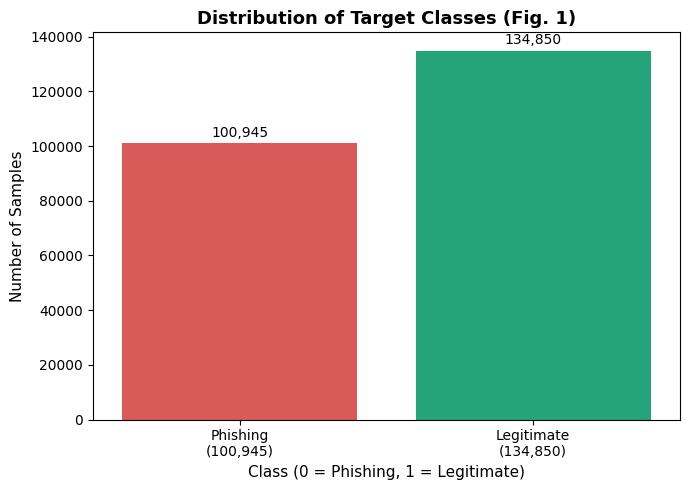

In [10]:
# Visualization of class balance
plt.figure(figsize=(7, 5))
ax = sns.countplot(x='label', data=df, palette=['#ef4444', '#10b981'])
plt.title("Distribution of Target Classes (Fig. 1)", fontsize=13, fontweight='bold')
plt.xlabel("Class (0 = Phishing, 1 = Legitimate)", fontsize=11)
plt.ylabel("Number of Samples", fontsize=11)
plt.xticks([0, 1], [f"Phishing\n({class_counts[0]:,})", f"Legitimate\n({class_counts[1]:,})"])
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=10, xytext=(0, 5), textcoords='offset points')
plt.tight_layout()
plt.show()


### Fig. 2: HTTPS Usage Across Legitimate and Phishing URLs (Paper Fig. 9)


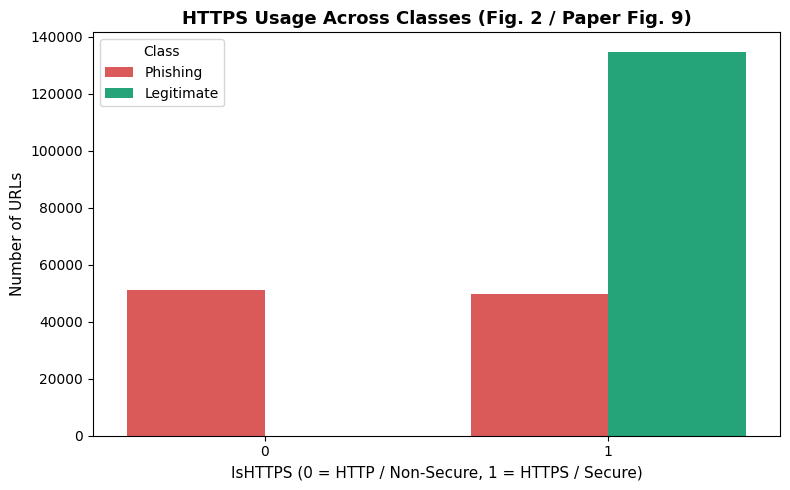

In [11]:
# HTTPS Usage by Class
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="IsHTTPS", hue="label", palette=['#ef4444', '#10b981'])
plt.title("HTTPS Usage Across Classes (Fig. 2 / Paper Fig. 9)", fontsize=13, fontweight='bold')
plt.xlabel("IsHTTPS (0 = HTTP / Non-Secure, 1 = HTTPS / Secure)", fontsize=11)
plt.ylabel("Number of URLs", fontsize=11)
plt.legend(title="Class", labels=["Phishing", "Legitimate"])
plt.tight_layout()
plt.show()


### Removal of Non-Predictive Identifier Columns (Section 4.4)


In [12]:
# Drop raw text/identifier columns that cause sample memorization
df_clean = df.drop(columns=[
    "FILENAME",
    "URL",
    "Domain",
    "Title",
    "TLD"
])
print("Dropped non-predictive columns: ['FILENAME', 'URL', 'Domain', 'Title', 'TLD']")
print("Remaining columns:", df_clean.shape[1])


Dropped non-predictive columns: ['FILENAME', 'URL', 'Domain', 'Title', 'TLD']
Remaining columns: 51


### Target Leakage Screening & Removal\nChecking for features that trivially separate the classes through target leakage.


In [13]:
# 1. Inspect URLSimilarityIndex
sim_legit = df.loc[df['label'] == 1, 'URLSimilarityIndex']
sim_phish = df.loc[df['label'] == 0, 'URLSimilarityIndex']
print(f"URLSimilarityIndex in Legitimate class: mean={sim_legit.mean():.2f}, std={sim_legit.std():.4f} (100% exact 100.0)")
print(f"URLSimilarityIndex in Phishing class:   mean={sim_phish.mean():.2f}, std={sim_phish.std():.4f}")

# 2. Inspect TLDLegitimateProb
tld_var = df.groupby('TLD')['TLDLegitimateProb'].nunique().max()
print(f"TLDLegitimateProb unique values per TLD: {tld_var} (Zero variance across all rows of same TLD)")

# Drop confirmed leaking features
leaking_features = ['URLSimilarityIndex', 'TLDLegitimateProb']
df_clean = df_clean.drop(columns=leaking_features)
print(f"Dropped leaking features: {leaking_features}")
print("Final clean predictor feature count:", df_clean.shape[1] - 1)


URLSimilarityIndex in Legitimate class: mean=100.00, std=0.0000 (100% exact 100.0)
URLSimilarityIndex in Phishing class:   mean=49.62, std=22.5721
TLDLegitimateProb unique values per TLD: 1 (Zero variance across all rows of same TLD)
Dropped leaking features: ['URLSimilarityIndex', 'TLDLegitimateProb']
Final clean predictor feature count: 48


### Fig. 3: Feature Correlation Heatmap (Paper Fig. 10)


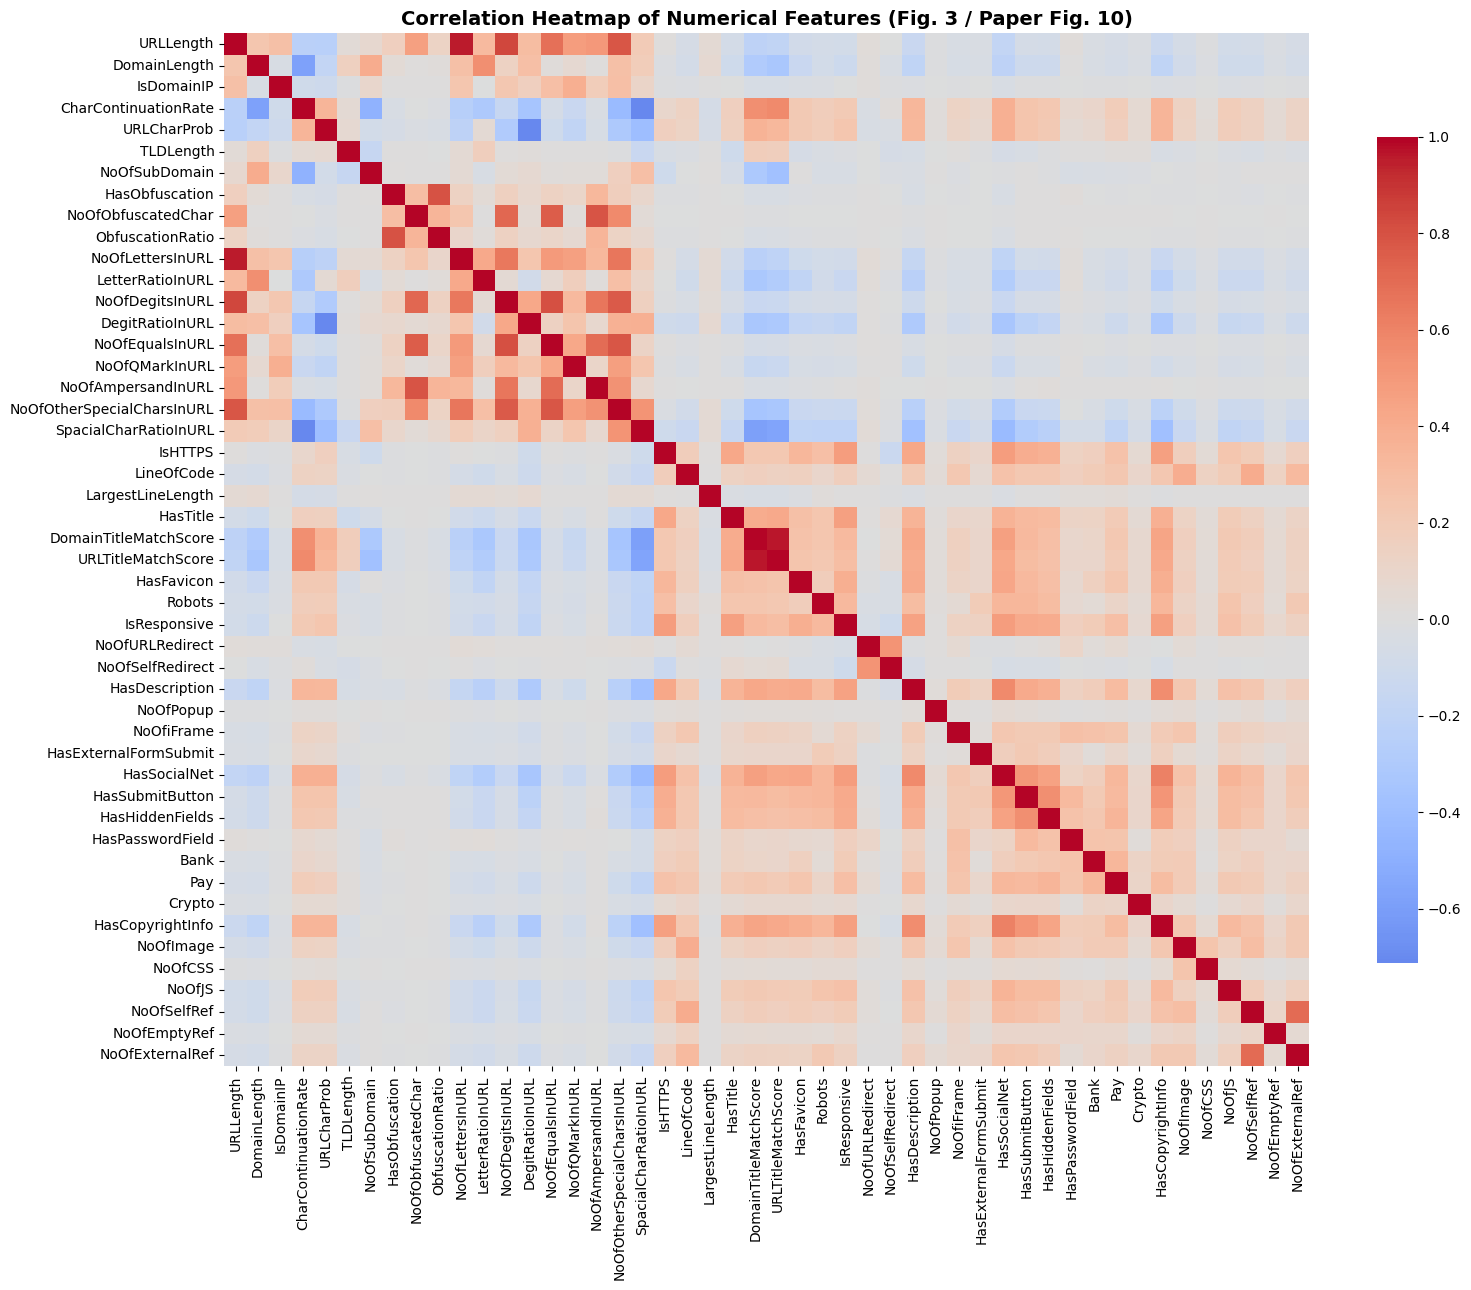

In [14]:
# Correlation Heatmap of usable numerical features
plt.figure(figsize=(16, 13))
corr = df_clean.drop(columns=['label']).corr()
sns.heatmap(corr, cmap="coolwarm", center=0, cbar_kws={'shrink': 0.8})
plt.title("Correlation Heatmap of Numerical Features (Fig. 3 / Paper Fig. 10)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### Separate Features (X) and Target (y)


In [15]:
X = df_clean.drop("label", axis=1)
y = df_clean["label"].values
feature_names = list(X.columns)

print("X shape:", X.shape, "(Input Features)")
print("y shape:", y.shape, "(Binary Labels: 1 = Legitimate, 0 = Phishing)")


X shape: (235795, 48) (Input Features)
y shape: (235795,) (Binary Labels: 1 = Legitimate, 0 = Phishing)


## 5. Stratified Train-Test Split (Section 4.6)\n**Crucial ML methodology note**: To strictly prevent silent data leakage, train-test splitting MUST happen before fitting StandardScaler or SelectKBest!


In [16]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"X_train: {X_train_raw.shape} | y_train: {y_train.shape}")
print(f"X_test : {X_test_raw.shape}  | y_test : {y_test.shape}")
print(f"Train class balance: Legitimate={np.mean(y_train==1)*100:.2f}%, Phishing={np.mean(y_train==0)*100:.2f}%")
print(f"Test class balance:  Legitimate={np.mean(y_test==1)*100:.2f}%, Phishing={np.mean(y_test==0)*100:.2f}%")


X_train: (188636, 48) | y_train: (188636,)
X_test : (47159, 48)  | y_test : (47159,)
Train class balance: Legitimate=57.19%, Phishing=42.81%
Test class balance:  Legitimate=57.19%, Phishing=42.81%


## 6. Feature Scaling (StandardScaler, Section 6)\nFitted ONLY on `X_train_raw` to prevent test-set leakage.


In [17]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

print("Scaled training features shape:", X_train_scaled.shape)
print("Scaled testing features shape :", X_test_scaled.shape)


Scaled training features shape: (188636, 48)
Scaled testing features shape : (47159, 48)


## 7. Feature Selection (SelectKBest with Mutual Information, Section 7)


In [18]:
# Compute Mutual Information on scaled training data
selector = SelectKBest(score_func=lambda X, y: mutual_info_classif(X, y, random_state=42), k=30)
X_train_sel30 = selector.fit_transform(X_train_scaled, y_train)
X_test_sel30 = selector.transform(X_test_scaled)

mi_scores = selector.scores_
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': mi_scores
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)
feature_importance['Rank'] = feature_importance.index + 1

print("Top 20 Features Ranked by Mutual Information:")
print(feature_importance.head(20).to_string(index=False))


Top 20 Features Ranked by Mutual Information:
                   Feature  Importance  Rank
                LineOfCode    0.601569     1
           NoOfExternalRef    0.561682     2
                 NoOfImage    0.546538     3
               NoOfSelfRef    0.528251     4
                    NoOfJS    0.503422     5
         LargestLineLength    0.486040     6
                   NoOfCSS    0.446405     7
              HasSocialNet    0.402268     8
          LetterRatioInURL    0.382759     9
          HasCopyrightInfo    0.336746    10
            HasDescription    0.294905    11
                   IsHTTPS    0.242134    12
NoOfOtherSpecialCharsInURL    0.240145    13
     DomainTitleMatchScore    0.207217    14
     SpacialCharRatioInURL    0.205648    15
           HasSubmitButton    0.201531    16
        URLTitleMatchScore    0.179324    17
           DegitRatioInURL    0.176353    18
           NoOfDegitsInURL    0.173093    19
              NoOfEmptyRef    0.172091    20


### Fig. 4: Top 20 Important Features Bar Plot (Paper Fig. 8)


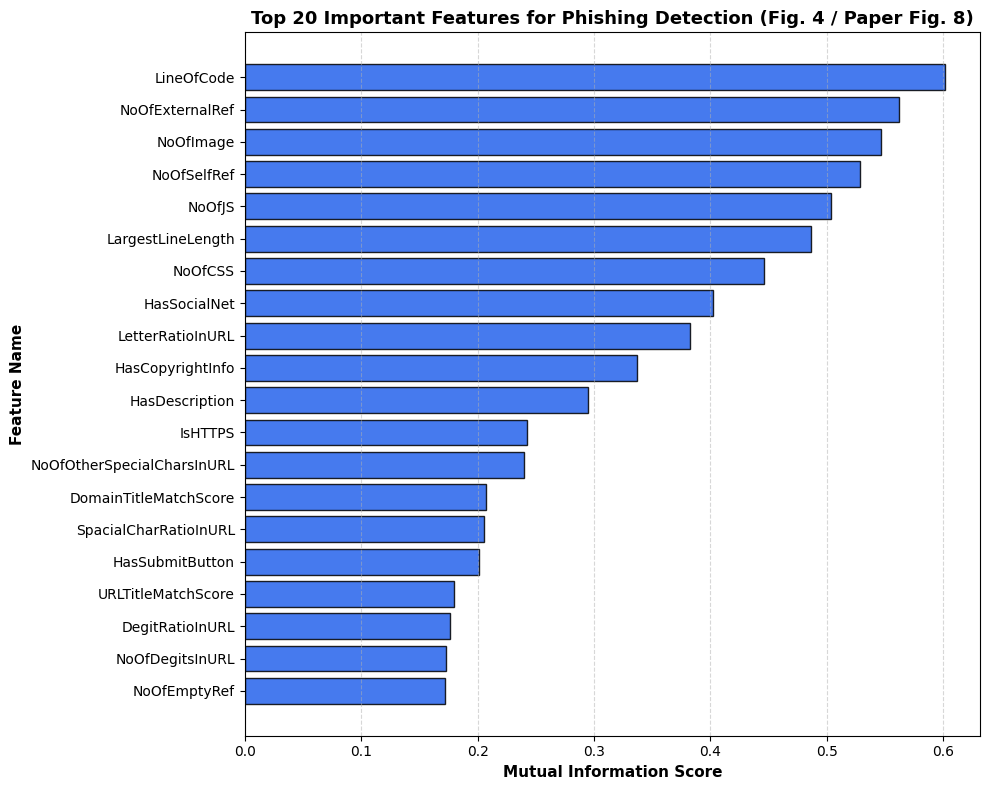

In [19]:
top20 = feature_importance.head(20).iloc[::-1]

plt.figure(figsize=(10, 8))
plt.barh(top20["Feature"], top20["Importance"], color='#2563eb', edgecolor='black', alpha=0.85)
plt.xlabel("Mutual Information Score", fontsize=11, fontweight='bold')
plt.ylabel("Feature Name", fontsize=11, fontweight='bold')
plt.title("Top 20 Important Features for Phishing Detection (Fig. 4 / Paper Fig. 8)", fontsize=13, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## 8. Build Proposed Artificial Neural Network (ANN, Section 8)\nArchitecture matching Table 3 of the paper:  \n`Input(30) -> Dense(128, relu) -> Dropout(0.3) -> Dense(64, relu) -> Dropout(0.3) -> Dense(32, relu) -> Dense(1, sigmoid)`


In [20]:
# Carve 10% stratified validation split out of training set
X_tr_ann, X_val_ann, y_tr_ann, y_val_ann = train_test_split(
    X_train_sel30,
    y_train,
    test_size=0.10,
    stratify=y_train,
    random_state=42
)

ann_model = Sequential([
    Input(shape=(30,)),
    Dense(128, activation="relu", name="Dense_1"),
    Dropout(0.30, name="Dropout_1"),
    Dense(64, activation="relu", name="Dense_2"),
    Dropout(0.30, name="Dropout_2"),
    Dense(32, activation="relu", name="Dense_3"),
    Dense(1, activation="sigmoid", name="Output_Sigmoid")
], name="Phishing_ANN_Proposed")

ann_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

ann_model.summary()


Model: "Phishing_ANN_Proposed"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ Dense_1 (Dense)                      │ (None, 128)                 │           3,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Dense_2 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Dense_3 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Output_Sigmoid (Dense)               │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,337 (56.00 KB)

 Trainable params: 14,337 (56.00 KB)

 Non-trainable params: 0 (0.00 B)

## 9. Train Proposed ANN Model\nUsing Adam optimizer, binary cross-entropy, batch size 512, and early stopping.


In [21]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

history = ann_model.fit(
    X_tr_ann,
    y_tr_ann,
    validation_data=(X_val_ann, y_val_ann),
    epochs=40,
    batch_size=512,
    callbacks=[early_stopping],
    verbose=1
)


Epoch 1/40
332/332 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9903 - loss: 0.0375 - val_accuracy: 0.9988 - val_loss: 0.0041
Epoch 2/40
332/332 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9987 - loss: 0.0040 - val_accuracy: 0.9993 - val_loss: 0.0030
Epoch 3/40
332/332 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9991 - loss: 0.0030 - val_accuracy: 0.9993 - val_loss: 0.0028
Epoch 4/40
332/332 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9993 - loss: 0.0024 - val_accuracy: 0.9994 - val_loss: 0.0026
Epoch 5/40
332/332 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9995 - loss: 0.0019 - val_accuracy: 0.9993 - val_loss: 0.0024
Epoch 6/40
332/332 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9995 - loss: 0.0016 - val_accuracy: 0.9995 - val_loss: 0.0022
Epoch 7/40
332/332 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9996 - loss: 0.0015 - val_accuracy: 0.9995 - val_loss: 0.0019
Epoch 8/40
332/332 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9996 - loss: 0.0013 - val_accuracy: 0.

### Fig. 5: ANN Training vs Validation Curves (Paper Fig. 11)


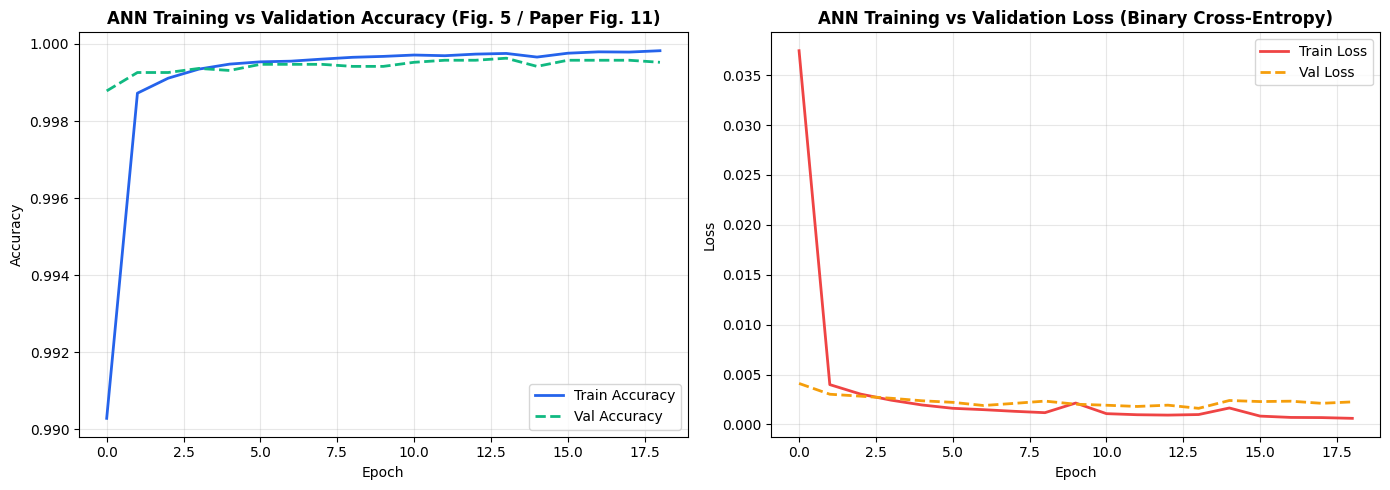

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy Curve
ax1.plot(history.history['accuracy'], label='Train Accuracy', color='#2563eb', lw=2)
ax1.plot(history.history['val_accuracy'], label='Val Accuracy', color='#10b981', lw=2, linestyle='--')
ax1.set_title("ANN Training vs Validation Accuracy (Fig. 5 / Paper Fig. 11)", fontsize=12, fontweight='bold')
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss Curve
ax2.plot(history.history['loss'], label='Train Loss', color='#ef4444', lw=2)
ax2.plot(history.history['val_loss'], label='Val Loss', color='#f59e0b', lw=2, linestyle='--')
ax2.set_title("ANN Training vs Validation Loss (Binary Cross-Entropy)", fontsize=12, fontweight='bold')
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 10. Evaluate Proposed ANN on Held-Out Test Set (Section 10 & 11)\n**Per Section 10 of Paper**: Phishing is treated as the Positive Class.


In [23]:
y_prob_legit = ann_model.predict(X_test_sel30, batch_size=512).ravel()
y_prob_phish = 1.0 - y_prob_legit
y_pred_phish = (y_prob_phish >= 0.5).astype(int)
y_test_phish = (y_test == 0).astype(int)

# Metrics
acc = accuracy_score(y_test_phish, y_pred_phish)
prec = precision_score(y_test_phish, y_pred_phish)
rec = recall_score(y_test_phish, y_pred_phish)
f1 = f1_score(y_test_phish, y_pred_phish)
auc = roc_auc_score(y_test_phish, y_prob_phish)
cm = confusion_matrix(y_test_phish, y_pred_phish)
tn, fp, fn, tp = cm.ravel()

print("=" * 60)
print("Table 4: Performance of Proposed ANN (Held-Out Test Set):")
print("=" * 60)
print(f"Accuracy:  {acc*100:.3f}%")
print(f"Precision: {prec*100:.3f}%")
print(f"Recall:    {rec*100:.3f}%")
print(f"F1-Score:  {f1*100:.3f}%")
print(f"ROC-AUC:   {auc:.5f}")
print("-" * 60)
print(f"TP (Phishing correctly caught):     {tp:,}")
print(f"TN (Legitimate correctly cleared):  {tn:,}")
print(f"FP (Legitimate falsely blocked):    {fp:,}")
print(f"FN (Phishing MISSED - Costliest!):  {fn:,}")
print("=" * 60)


93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Table 4: Performance of Proposed ANN (Held-Out Test Set):
Accuracy:  99.964%
Precision: 99.950%
Recall:    99.965%
F1-Score:  99.958%
ROC-AUC:   1.00000
------------------------------------------------------------
TP (Phishing correctly caught):     20,182
TN (Legitimate correctly cleared):  26,960
FP (Legitimate falsely blocked):    10
FN (Phishing MISSED - Costliest!):  7


### Fig. 6: Confusion Matrix Heatmap


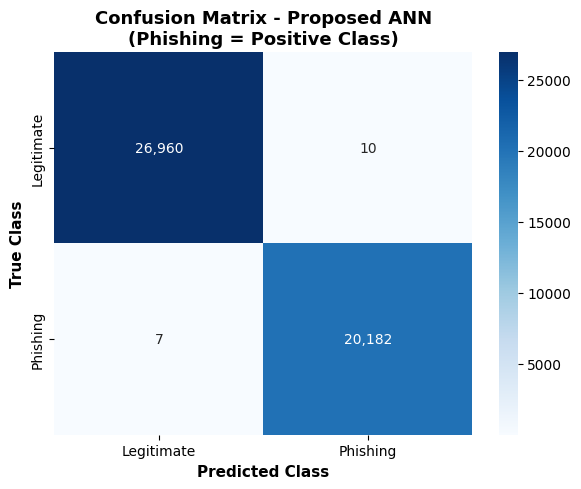

In [24]:
plt.figure(figsize=(6, 5))
sns.heatmap([[tn, fp], [fn, tp]], annot=True, fmt=',d', cmap="Blues",
            xticklabels=["Legitimate", "Phishing"],
            yticklabels=["Legitimate", "Phishing"])
plt.title("Confusion Matrix - Proposed ANN\n(Phishing = Positive Class)", fontsize=13, fontweight='bold')
plt.xlabel("Predicted Class", fontsize=11, fontweight='bold')
plt.ylabel("True Class", fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


## 11. Feature Selection Ablation Study (Section 13, Table 7)\nComparing ANN with Mutual Information (30 features) vs ANN without feature selection (All 48 usable features).


In [25]:
X_tr_ab, X_val_ab, y_tr_ab, y_val_ab = train_test_split(
    X_train_scaled,
    y_train,
    test_size=0.10,
    stratify=y_train,
    random_state=42
)

ablation_model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(128, activation="relu"),
    Dropout(0.30),
    Dense(64, activation="relu"),
    Dropout(0.30),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

ablation_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
ablation_model.fit(
    X_tr_ab, y_tr_ab,
    validation_data=(X_val_ab, y_val_ab),
    epochs=40, batch_size=512,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=0)],
    verbose=0
)

# Evaluate Ablation Model
y_prob_ab_phish = 1.0 - ablation_model.predict(X_test_scaled, batch_size=512).ravel()
y_pred_ab_phish = (y_prob_ab_phish >= 0.5).astype(int)

ablation_df = pd.DataFrame([
    {
        "Configuration": "ANN without feature selection",
        "Features": X.shape[1],
        "Accuracy": accuracy_score(y_test_phish, y_pred_ab_phish),
        "Precision": precision_score(y_test_phish, y_pred_ab_phish),
        "Recall": recall_score(y_test_phish, y_pred_ab_phish),
        "F1-Score": f1_score(y_test_phish, y_pred_ab_phish),
        "ROC-AUC": roc_auc_score(y_test_phish, y_prob_ab_phish)
    },
    {
        "Configuration": "ANN with Mutual Information",
        "Features": 30,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
        "ROC-AUC": auc
    }
])

print("Table 7: Feature Selection Ablation Study Results:")
print(ablation_df.to_string(index=False))


93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Table 7: Feature Selection Ablation Study Results:
                Configuration  Features  Accuracy  Precision   Recall  F1-Score  ROC-AUC
ANN without feature selection        48  0.999661   0.999653 0.999554  0.999604 0.999998
  ANN with Mutual Information        30  0.999640   0.999505 0.999653  0.999579 1.000000


## 12. Comparison with Traditional Machine Learning Models (Section 12, Table 6)\nComparing Proposed ANN with Logistic Regression, Decision Tree, Random Forest, LinearSVC, and XGBoost on the identical 30 features.


In [26]:
models = [
    ("Logistic Regression", LogisticRegression(max_iter=1000, random_state=42)),
    ("Decision Tree", DecisionTreeClassifier(random_state=42)),
    ("Random Forest", RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
    ("Support Vector Machine (LinearSVC)", LinearSVC(dual='auto', random_state=42)),
    ("XGBoost", XGBClassifier(n_estimators=100, eval_metric='logloss', random_state=42, n_jobs=-1))
]

comp_results = []
for name, clf in models:
    clf.fit(X_train_sel30, y_train)
    y_pred = clf.predict(X_test_sel30)
    
    if hasattr(clf, "predict_proba"):
        p_phish = clf.predict_proba(X_test_sel30)[:, 0]
    elif hasattr(clf, "decision_function"):
        p_phish = -clf.decision_function(X_test_sel30)
    else:
        p_phish = (y_pred == 0).astype(float)
        
    p_pred_phish = (y_pred == 0).astype(int)
    cm_i = confusion_matrix(y_test_phish, p_pred_phish)
    tn_i, fp_i, fn_i, tp_i = cm_i.ravel()
    
    comp_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test_phish, p_pred_phish),
        "Precision": precision_score(y_test_phish, p_pred_phish),
        "Recall": recall_score(y_test_phish, p_pred_phish),
        "F1-Score": f1_score(y_test_phish, p_pred_phish),
        "ROC-AUC": roc_auc_score(y_test_phish, p_phish),
        "TP": tp_i, "TN": tn_i, "FP": fp_i, "FN": fn_i
    })

# Add ANN
comp_results.append({
    "Model": "Proposed ANN (30 Features)",
    "Accuracy": acc, "Precision": prec, "Recall": rec, "F1-Score": f1, "ROC-AUC": auc,
    "TP": tp, "TN": tn, "FP": fp, "FN": fn
})

comp_df = pd.DataFrame(comp_results)
print("Table 6: Consolidated Model Comparison (Held-Out Test Set):")
print(comp_df.to_string(index=False))


Table 6: Consolidated Model Comparison (Held-Out Test Set):
                             Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC    TP    TN  FP  FN
               Logistic Regression  0.998813   0.998910 0.998316  0.998613 0.999991 20155 26948  22  34
                     Decision Tree  0.998473   0.997921 0.998514  0.998217 0.998478 20159 26928  42  30
                     Random Forest  0.999724   0.999851 0.999505  0.999678 1.000000 20179 26967   3  10
Support Vector Machine (LinearSVC)  0.999640   0.999703 0.999455  0.999579 0.999995 20178 26964   6  11
                           XGBoost  0.999852   0.999901 0.999752  0.999827 1.000000 20184 26968   2   5
        Proposed ANN (30 Features)  0.999640   0.999505 0.999653  0.999579 1.000000 20182 26960  10   7


### Fig. 7: Model Comparison Bar Chart


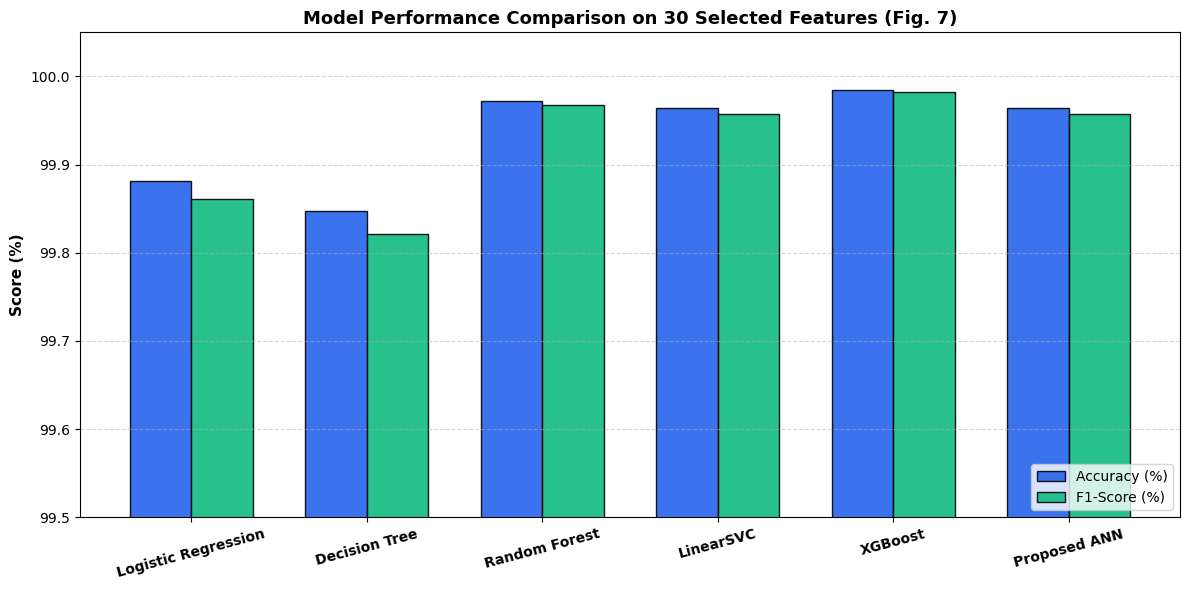

In [27]:
models_list = comp_df["Model"].tolist()
acc_list = [v * 100 for v in comp_df["Accuracy"].tolist()]
f1_list = [v * 100 for v in comp_df["F1-Score"].tolist()]

x_idx = np.arange(len(models_list))
width = 0.35

plt.figure(figsize=(12, 6))
plt.bar(x_idx - width/2, acc_list, width, label='Accuracy (%)', color='#2563eb', edgecolor='black', alpha=0.9)
plt.bar(x_idx + width/2, f1_list, width, label='F1-Score (%)', color='#10b981', edgecolor='black', alpha=0.9)
plt.ylabel('Score (%)', fontsize=11, fontweight='bold')
plt.title('Model Performance Comparison on 30 Selected Features (Fig. 7)', fontsize=13, fontweight='bold')
plt.xticks(x_idx, [m.replace("Support Vector Machine (LinearSVC)", "LinearSVC").replace("Proposed ANN (30 Features)", "Proposed ANN") for m in models_list], rotation=15, fontsize=10, fontweight='bold')
plt.ylim([99.5, 100.05])
plt.legend(loc='lower right', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
